In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [5]:
data = sns.load_dataset('iris')
train, test = train_test_split(
    data, test_size=0.4,
    stratify= data['species'],
    random_state = 23
)


In [7]:
fn = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
cn = ['setosa', 'versicolor', 'virginica']

x_train = train[fn]
y_train = train['species']

# Conjunto de pruebas siguiendo el modelo y =mX + b
x_test = test[fn]
y_test = test['species']

In [9]:
# Clasficador
modelo_gnb = GaussianNB()
modelo_gnb.fit(x_train, y_train)
prediccion = modelo_gnb.predict(x_test)

In [10]:
eficiencia = metrics.accuracy_score(prediccion, y_test)
eficiencia

0.9666666666666667

In [11]:
test['y_pred'] = prediccion
test

,sepal_length,sepal_width,petal_length,petal_width,species,y_pred
26,5.0,3.4,1.6,0.4,setosa,setosa
142,5.8,2.7,5.1,1.9,virginica,virginica
68,6.2,2.2,4.5,1.5,versicolor,versicolor
64,5.6,2.9,3.6,1.3,versicolor,versicolor
37,4.9,3.6,1.4,0.1,setosa,setosa
31,5.4,3.4,1.5,0.4,setosa,setosa
39,5.1,3.4,1.5,0.2,setosa,setosa
88,5.6,3.0,4.1,1.3,versicolor,versicolor
121,5.6,2.8,4.9,2.0,virginica,virginica
38,4.4,3.0,1.3,0.2,setosa,setosa


In [13]:
# precisión, sensibilidad, resolución
# capacidad de predecir qué es, 
print(metrics.classification_report(y_test, prediccion))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.91      1.00      0.95        20
   virginica       1.00      0.90      0.95        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



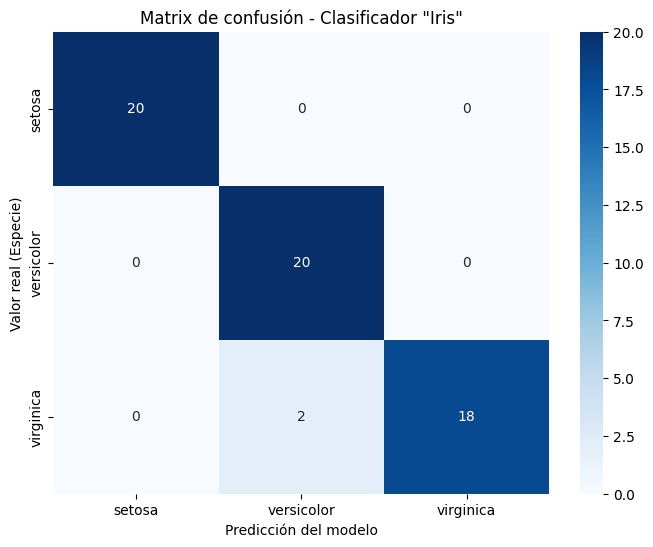

In [15]:
cm = metrics.confusion_matrix(y_test, prediccion)
fig = plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=modelo_gnb.classes_,
            yticklabels=modelo_gnb.classes_
)
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real (Especie)')
plt.title('Matrix de confusión - Clasificador "Iris"')
plt.show()